# Study 781 — Quad-Witching-Hangover — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `a7fba5aedc7e`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from quad_witching_hangover import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} quad-witching Fridays resolved")


panel loaded; 84 of 84 quad-witching Fridays resolved


## 1. One-sample *t* across independent quad-witching quarters

Each quad-witching Friday is one independent, non-overlapping event, so the unit is a one-sample *t* of the per-quarter forward return — **not** a daily panel (which would fake precision).

In [2]:
for label, col in [('1wk hangover','post_s'),('2wk give-back','post_l'),('1wk run-in','pre')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<14s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}')

1wk hangover   n=84  mean=+0.075%  sd=2.48%  t=+0.276
2wk give-back  n=84  mean=+0.375%  sd=3.67%  t=+0.937
1wk run-in     n=84  mean=+0.188%  sd=2.61%  t=+0.660


## 2. Random-window placebo — is the hangover inside the luck cloud?

For each event we redraw a random, non-quad-witching 1-week window on SPY and recompute the return; 20 seeds × 200 draws. SPY drifts up, so the placebo mean is positive; if the observed hangover were real it would sit in the **left** tail.

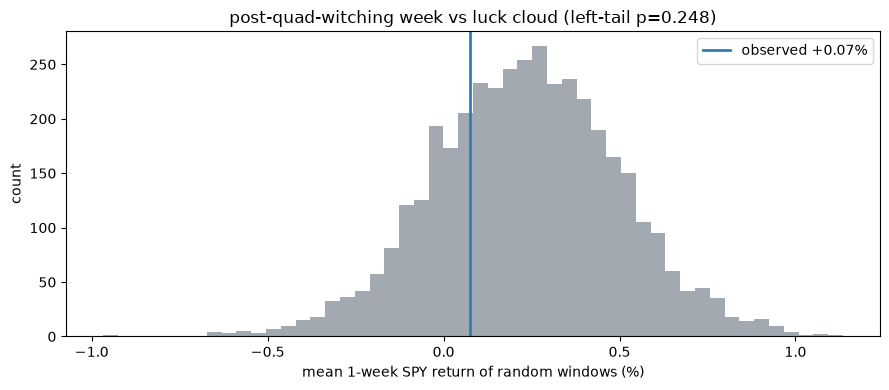

placebo: {'obs': 0.0007, 'placebo_mean': 0.0024, 'placebo_sd': 0.0026, 'p_value': 0.2477, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'post_s', k=5, tail='left')
spy = prices[dt.INSTRUMENT]; common = spy.index.sort_values()
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(0, len(common)-6))
        vals.append(float(spy.loc[common[p+5]]/spy.loc[common[p]] - 1.0))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#2c7fb8', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 1-week SPY return of random windows (%)'); ax.set_ylabel('count')
ax.set_title(f"post-quad-witching week vs luck cloud (left-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is the (non-)effect robust, or one quarter?

In [4]:
x = inc['post_s'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = +0.276
jackknife t range [-0.226, +0.592] over 84 leave-one-out draws


## 4. Tradability — net of costs

Calendar-known entry, so the signal window and the tradable window are the same. To "trade the hangover" you'd **short** a window whose gross return is *positive* — you lose before costs and more after. There is no edge in either direction.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('post_s','1wk hangover'),('post_l','2wk give-back')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<14s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

1wk hangover   gross +0.075% (t=+0.28)  net@5 -0.025% (t=-0.09)  net@10 -0.125% (t=-0.46)
2wk give-back  gross +0.375% (t=+0.94)  net@5 +0.275% (t=+0.69)  net@10 +0.175% (t=+0.44)


## 5. Synthetic positive control — the detector works, the tape has nothing

The one-sample-*t* detector must recover a *planted* post-event hangover and stay controlled on the null. The null mean *t* is slightly positive because the synthetic world (like SPY) has +drift leaking into a self-benchmarked *t* — the same reason the real hangover reads mildly positive.

null: mean t=+0.67 sd=0.93  |t|>=2 in 3/20 seeds
planted -0.6%: mean +0.040%  t=+0.16
planted -1.2%: mean -0.560%  t=-2.19


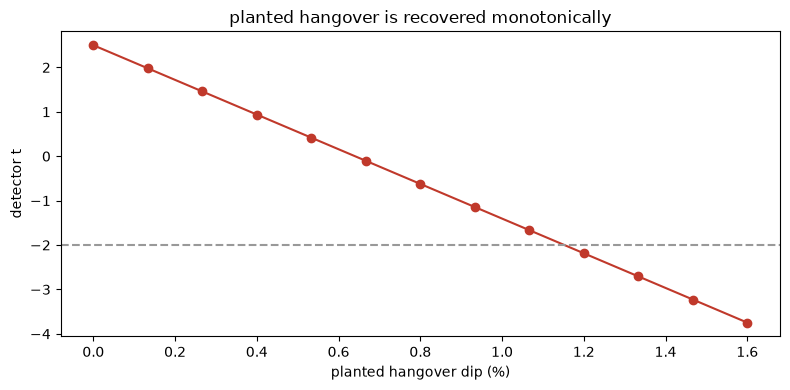

In [6]:
null_ts = np.array([st.synthetic_detect(dip=0.0, seed=793+s, k=5)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for d in (0.006, 0.012):
    r = st.synthetic_detect(dip=d, seed=793, k=5)
    print(f'planted -{d*100:.1f}%: mean {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
dips = np.linspace(0, 0.016, 13)
ts = [st.synthetic_detect(dip=d, seed=793, k=5)['t'] for d in dips]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(dips*100, ts, 'o-', color='#c0392b')
ax.axhline(-2, color='0.6', ls='--'); ax.set_xlabel('planted hangover dip (%)'); ax.set_ylabel('detector t')
ax.set_title('planted hangover is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: None.** The week after quad-witching returns +0.08% (*t* = +0.28) — *positive*, opposite the folklore; the 2-week window is +0.38% (*t* = +0.94); the placebo is dead-centre (left-tail p = 0.25 / 0.36) and the jackknife *t* is pinned near zero (−0.23…+0.59). **Tradability: Mirage.** "Shorting the hangover" shorts a positive window and loses gross; costs sink the 1-week leg outright. No edge in either direction.